In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv('punjab stubble data.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 270442, Columns: 13


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21264\297576248.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('punjab stubble data.csv')


In [3]:
print("Missing values:",df.isnull().sum())
print("Summary of the dataset:")
print(df.describe())

Missing values: Year                                                                                      0
District                                                                                  0
Block                                                                                     0
Satellite                                                                                 0
Date                                                                                      0
Time (IST)                                                                                9
Day / Night                                                                               0
Fire Power(W/m2)                                                                       1419
Corrected_long                                                                            0
corrected_lat                                                                             0
latlong                                                         

In [4]:
# To Remove the last two columns
df = df.iloc[:, :-2]

# Table after dropping the last two columns
print("--- Missing Values After Dropping Redundant Columns ---")
print(df.isnull().sum())

--- Missing Values After Dropping Redundant Columns ---
Year                   0
District               0
Block                  0
Satellite              0
Date                   0
Time (IST)             9
Day / Night            0
Fire Power(W/m2)    1419
Corrected_long         0
corrected_lat          0
latlong                0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

def is_row_shifted(row):
    # 1. Date format check: Should contain '-' or '/'
    is_date_valid = ('-' in str(row['Date']) or '/' in str(row['Date']))
    
    # 2. Time format check: Should contain ':'
    is_time_valid = (':' in str(row['Time (IST)']))
    
    # 3. Fire Power check: Should be numeric (not 'Day' or 'Night')
    # If 'Day / Night' contains a numeric value, the row is likely shifted
    day_night_val = str(row['Day / Night'])
    is_day_night_valid = (day_night_val in ['Day', 'Night'])
    
    # The row is broken if ANY of these conditions fail
    return not (is_date_valid and is_time_valid and is_day_night_valid)

# Identify all broken rows
shifted_mask = df.apply(is_row_shifted, axis=1)

# To Perform the repair (Shift values back to the right)
df.loc[shifted_mask, 'Fire Power(W/m2)'] = df.loc[shifted_mask, 'Day / Night']
df.loc[shifted_mask, 'Day / Night'] = df.loc[shifted_mask, 'Time (IST)']
df.loc[shifted_mask, 'Time (IST)'] = df.loc[shifted_mask, 'Date']
df.loc[shifted_mask, 'Date'] = np.nan # The original date cell is now empty because it shifted

print(f"Repaired {shifted_mask.sum()} shifted rows.")

Repaired 44 shifted rows.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21264\4174175563.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Day' 'Day' 'Day' 'Day' 'Day' 'Day' 'Day' 'Day' 'Night' '10.82' '12.86'
 '6.6' '1.9' '4.4' '1.7' '3.2' '4.1' '4.9' '4.7' '3.8' '3.1' '2.9' '2.2'
 '3.6' '4.4' '3.1' '2.7' '1.5' '2.1' '6' '2.9' '4.2' '4.2' '22.2' '3.9'
 '4.8' '3.6' '4.7' '2.7' '2.8' '6.4' '2.4' '2' '2.6']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[shifted_mask, 'Fire Power(W/m2)'] = df.loc[shifted_mask, 'Day / Night']


In [6]:
df.to_csv('partially_cleaned_stubble_data.csv', index=False)
print("Created new dataset")

Created new dataset


In [7]:
df['Day / Night'] = df['Day / Night'].replace('D', 'Day');
#df.to_csv("Sample1.csv", index=False)
print("Created")


Created


In [8]:
print("--- Missing Values After Dropping Redundant Columns ---")
print(df.isnull().sum())

--- Missing Values After Dropping Redundant Columns ---
Year                   0
District               0
Block                  0
Satellite              0
Date                  44
Time (IST)             0
Day / Night            9
Fire Power(W/m2)    1384
Corrected_long         0
corrected_lat          0
latlong                0
dtype: int64


In [ ]:
# 1.To Ensure Year and Date are in the correct format for sorting
df['Year'] = df['Year'].astype(int)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 2. Sort the dataset values
df = df.sort_values(by=['Year', 'Date', 'Time (IST)'])

# 3. To Forward Fill the empty dates
df['Date'] = df['Date'].ffill()

print("Data sorted and cleaned. Remaining nulls in Date:", df['Date'].isnull().sum())

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21264\4274284204.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


Data sorted and cleaned. Remaining nulls in Date: 0


In [10]:
#df.to_csv('Sample2.csv', index=False)
print('created')

created


In [11]:

print("--- Missing Values After Dropping Redundant Columns ---")
print(df.isnull().sum())


--- Missing Values After Dropping Redundant Columns ---
Year                   0
District               0
Block                  0
Satellite              0
Date                   0
Time (IST)             0
Day / Night            9
Fire Power(W/m2)    1384
Corrected_long         0
corrected_lat          0
latlong                0
dtype: int64


In [ ]:
# Force Fire Power(W/m2) column to be numeric. 
df['Fire Power(W/m2)'] = pd.to_numeric(df['Fire Power(W/m2)'], errors='coerce')

# filling with the median firepower of the same district and date
df['Fire Power(W/m2)'] = df.groupby(['District', 'Date'])['Fire Power(W/m2)'].transform(lambda x: x.fillna(x.median()))

# still null, fill with global median
df['Fire Power(W/m2)'] = df['Fire Power(W/m2)'].fillna(df['Fire Power(W/m2)'].median())

print("--- Missing Values After Dropping Redundant Columns ---")
print(df.isnull().sum())


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\AppData\Roamin

--- Missing Values After Dropping Redundant Columns ---
Year                0
District            0
Block               0
Satellite           0
Date                0
Time (IST)          0
Day / Night         9
Fire Power(W/m2)    0
Corrected_long      0
corrected_lat       0
latlong             0
dtype: int64


In [13]:
df = df.dropna(subset=['Day / Night'])

print("--- Missing Values After Dropping Redundant Columns ---")
print(df.isnull().sum())


--- Missing Values After Dropping Redundant Columns ---
Year                0
District            0
Block               0
Satellite           0
Date                0
Time (IST)          0
Day / Night         0
Fire Power(W/m2)    0
Corrected_long      0
corrected_lat       0
latlong             0
dtype: int64


In [14]:
#df.to_csv('Cleaned_stubble_data.csv', index=False)
print('Cleaned data saved to Cleaned_stubble_data.csv')

Cleaned data saved to Cleaned_stubble_data.csv


In [ ]:
# drop latlong column
df = df.drop(columns=['latlong'])

# 2. Rename for clarity 
df = df.rename(columns={'Corrected_long': 'Longitude', 'corrected_lat': 'Latitude'})

#df.to_csv('Final_Cleaned_stubble_data.csv', index=False)
print('Created')

Created


In [ ]:
# new column month to pull monthly data insights
df['Month']=df['Date'].dt.month
print('Month column created')

# 1. 3 conditions
conditions = [
    (df['Fire Power(W/m2)'] <= 5),                 # Condition 1
    (df['Fire Power(W/m2)'] > 5) & (df['Fire Power(W/m2)'] <= 20), # Condition 2
    (df['Fire Power(W/m2)'] > 20)                  # Condition 3
]

# 2. the corresponding outputs for each condition
choices = ['Low Intensity', 'Medium Intensity', 'High Intensity']

# 3. Create the new column using np.select
df['Fire_Severity'] = np.select(conditions, choices, default='Unknown')

#to ensure there is no missing values in the new column, we can check for nulls
print("--- Missing Values After Dropping Redundant Columns ---")
print(df.isnull().sum())




Month column created
--- Missing Values After Dropping Redundant Columns ---
Year                0
District            0
Block               0
Satellite           0
Date                0
Time (IST)          0
Day / Night         0
Fire Power(W/m2)    0
Longitude           0
Latitude            0
Month               0
Fire_Severity       0
dtype: int64


In [17]:
df.head()

,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Longitude,Latitude,Month,Fire_Severity
78158,2018,FATEHGARH SAHIB,ALMOH,S-NPP,2018-10-01,02:18:00,Night,0.8,76.286,30.642,10,Low Intensity
78159,2018,FATEHGARH SAHIB,ALMOH,S-NPP,2018-10-01,02:18:00,Night,0.4,76.287,30.645,10,Low Intensity
78160,2018,FIROZPUR,FIROZPUR,S-NPP,2018-10-01,13:36:00,Day,5.2,74.486,30.927,10,Medium Intensity
78161,2018,NAWASHAHR,NAWASHAHR,S-NPP,2018-10-01,13:36:00,Day,2.4,76.184,31.133,10,Low Intensity
78162,2018,HOSHIARPUR,GARHSHANKAR,S-NPP,2018-10-01,13:36:00,Day,2.1,75.901,31.314,10,Low Intensity


In [19]:
month_map={1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
           7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

df['Month']=df['Month'].map(month_map)
df.head(10)

,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Longitude,Latitude,Month,Fire_Severity
78158,2018,FATEHGARH SAHIB,ALMOH,S-NPP,2018-10-01,02:18:00,Night,0.8,76.286,30.642,October,Low Intensity
78159,2018,FATEHGARH SAHIB,ALMOH,S-NPP,2018-10-01,02:18:00,Night,0.4,76.287,30.645,October,Low Intensity
78160,2018,FIROZPUR,FIROZPUR,S-NPP,2018-10-01,13:36:00,Day,5.2,74.486,30.927,October,Medium Intensity
78161,2018,NAWASHAHR,NAWASHAHR,S-NPP,2018-10-01,13:36:00,Day,2.4,76.184,31.133,October,Low Intensity
78162,2018,HOSHIARPUR,GARHSHANKAR,S-NPP,2018-10-01,13:36:00,Day,2.1,75.901,31.314,October,Low Intensity
78163,2018,AMRITSAR,BABA BAKALA,S-NPP,2018-10-01,13:36:00,Day,2.9,75.078,31.618,October,Low Intensity
78164,2018,AMRITSAR,BABA BAKALA,S-NPP,2018-10-01,13:36:00,Day,3.4,75.103,31.618,October,Low Intensity
78165,2018,AMRITSAR,AMRITSAR I,S-NPP,2018-10-01,13:36:00,Day,4.0,75.060,31.672,October,Low Intensity
78166,2018,NAoM. oRf IeTvSenAtRs,AMRITSAR II,S-NPP,2018-10-01,13:36:00,Day,3.2,75.007,31.682,October,Low Intensity
78167,2018,AMRITSAR,AMRITSAR II,S-NPP,2018-10-01,13:36:00,Day,2.5,74.988,31.693,October,Low Intensity


In [20]:
print(df['District'].value_counts())
print(len(df))

District
SANGRUR                  34696
FIROZPUR                 30446
BATHINDA                 25315
MUKTSAR                  20740
PATIALA                  18978
MANSA                    17142
LUDHIANA                 16666
BARNALA                  16298
MOGA                     16255
TARN TARAN               14975
FARIDKOT                 13772
FAZILKA                  10090
JALANDHAR                 7454
AMRITSAR                  7241
GURDASPUR                 6049
KAPURTHALA                5563
FATEHGARH SAHIB           4814
HOSHIARPUR                1275
RUPNAGAR                   740
NAWASHAHR                  677
SBS NAGAR                  629
SAS NAGAR                  446
SAS NAGAR (MOHALI)         148
PATHANKOT                   20
Amritsar                     2
NAoM. oRf IeTvSenAtRs        1
No. of\nTARN TARAN           1
Name: count, dtype: int64
270433


In [ ]:
# 1.the exact text values want to get rid of
garbage_values = ['NAoM. oRf IeTvSenAtRs', 'No. of\nTARN TARAN']

# 2. Keep only the rows that are NOT in that list
df = df[~df['District'].isin(garbage_values)]

# 3. Verify the result
print(df['District'].value_counts())
print(len(df))

District
SANGRUR               34696
FIROZPUR              30446
BATHINDA              25315
MUKTSAR               20740
PATIALA               18978
MANSA                 17142
LUDHIANA              16666
BARNALA               16298
MOGA                  16255
TARN TARAN            14975
FARIDKOT              13772
FAZILKA               10090
JALANDHAR              7454
AMRITSAR               7241
GURDASPUR              6049
KAPURTHALA             5563
FATEHGARH SAHIB        4814
HOSHIARPUR             1275
RUPNAGAR                740
NAWASHAHR               677
SBS NAGAR               629
SAS NAGAR               446
SAS NAGAR (MOHALI)      148
PATHANKOT                20
Amritsar                  2
Name: count, dtype: int64
270431


In [22]:
df.head()


,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Longitude,Latitude,Month,Fire_Severity
78158,2018,FATEHGARH SAHIB,ALMOH,S-NPP,2018-10-01,02:18:00,Night,0.8,76.286,30.642,October,Low Intensity
78159,2018,FATEHGARH SAHIB,ALMOH,S-NPP,2018-10-01,02:18:00,Night,0.4,76.287,30.645,October,Low Intensity
78160,2018,FIROZPUR,FIROZPUR,S-NPP,2018-10-01,13:36:00,Day,5.2,74.486,30.927,October,Medium Intensity
78161,2018,NAWASHAHR,NAWASHAHR,S-NPP,2018-10-01,13:36:00,Day,2.4,76.184,31.133,October,Low Intensity
78162,2018,HOSHIARPUR,GARHSHANKAR,S-NPP,2018-10-01,13:36:00,Day,2.1,75.901,31.314,October,Low Intensity


In [23]:
print(df['District'].value_counts())
print(len(df))

District
SANGRUR               34696
FIROZPUR              30446
BATHINDA              25315
MUKTSAR               20740
PATIALA               18978
MANSA                 17142
LUDHIANA              16666
BARNALA               16298
MOGA                  16255
TARN TARAN            14975
FARIDKOT              13772
FAZILKA               10090
JALANDHAR              7454
AMRITSAR               7241
GURDASPUR              6049
KAPURTHALA             5563
FATEHGARH SAHIB        4814
HOSHIARPUR             1275
RUPNAGAR                740
NAWASHAHR               677
SBS NAGAR               629
SAS NAGAR               446
SAS NAGAR (MOHALI)      148
PATHANKOT                20
Amritsar                  2
Name: count, dtype: int64
270431


In [24]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df['Block'].value_counts())
    
print(f"\nTotal Rows: {len(df)}")

Block
ZIRA                          10209
FIROZPUR                       9569
BATHINDA                       8948
BARNALA                        8942
JALALABAD                      8850
SUNAM                          8650
FARIDKOT                       8372
RAMPURA PHUL                   7767
MUKTSAR                        7389
MANSA                          7120
PATTI                          6888
SANGRUR                        6590
BUDHLADA                       6186
SAMANA                         5841
MALAUT                         5783
FAZILKA                        5779
BAGHA PURANA                   5621
TAPPA                          5122
DHURI                          5089
JAGRAON                        4960
TALWANDI SABO                  4883
GIDDARBAHA                     4854
PATIALA                        4834
KHADOOR SAHIB                  4761
MOONAK                         4757
NABHA                          4406
MALERKOTLA                     3435
MOGA                  

In [25]:
corrections = {
    'KOT ISE KHAN AT\nDHARAMKOT': 'KOT ISE KHAN',
    'KOT BHAI AT\nGIDDERBAHA': 'KOT BHAI',
    'ARNIWALA SHEIKH\nSUBANPUR': 'ARNIWALA SHEIKH',
    'GURUHAR\nSAHAI': 'GURUHAR SAHAI',
    'SIDHWAN\nBET': 'SIDHWAN BET',
    'NAUSHERA\nPANNUAN': 'NAUSHERA PANNUAN',
    'TALWANDI\nSABO': 'TALWANDI SABO',
    'GARH\nSHANKAR': 'GARH SHANKAR',
    'HARSHA\nCHHINA': 'HARSHA CHHINA',
    'BASSI\nPATHANAN': 'BASSI PATHANAN',
    'KOT ISE KHAN AT DHARAMKOT': 'KOT ISE KHAN',
    'KOT BHAI AT GIDDERBAHA': 'KOT BHAI',
    'ARNIWALA SHEIKH SUBANPUR': 'ARNIWALA SHEIKH'
}
df['Block'] = df['Block'].replace(corrections)

garbage_value = ['HNOo.S oHf IeAveRnPtsUR',]

# 2. Keep only the rows that are NOT in that list
df = df[~df['Block'].isin(garbage_value)]


with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df['Block'].value_counts())
    
print(f"\nTotal Rows: {len(df)}")


Block
ZIRA                  10209
FIROZPUR               9569
BATHINDA               8948
BARNALA                8942
JALALABAD              8850
SUNAM                  8650
FARIDKOT               8372
RAMPURA PHUL           7767
MUKTSAR                7389
MANSA                  7120
PATTI                  6888
SANGRUR                6590
BUDHLADA               6186
SAMANA                 5841
MALAUT                 5783
FAZILKA                5779
BAGHA PURANA           5621
TAPPA                  5122
DHURI                  5089
JAGRAON                4960
TALWANDI SABO          4884
GIDDARBAHA             4854
PATIALA                4834
KHADOOR SAHIB          4761
MOONAK                 4757
NABHA                  4406
MALERKOTLA             3435
MOGA                   3295
JAITO                  3167
NIHAL SINGH WALA       2893
SARDULGARH             2801
RAIKOT                 2704
BATALA                 2334
AJNALA                 2082
SULTANPUR LODHI        2012
PHILLAUR      

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21264\3457136609.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Block'] = df['Block'].replace(corrections)


In [27]:
df['Block']=df['Block'].str.upper()

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df['Block'].value_counts())

print(len(df))

Block
ZIRA                  10209
FIROZPUR               9569
BATHINDA               8948
BARNALA                8942
JALALABAD              8850
SUNAM                  8650
FARIDKOT               8372
RAMPURA PHUL           7767
MUKTSAR                7389
MANSA                  7120
PATTI                  6888
SANGRUR                6590
BUDHLADA               6186
SAMANA                 5841
MALAUT                 5783
FAZILKA                5779
BAGHA PURANA           5621
TAPPA                  5122
DHURI                  5089
JAGRAON                4960
TALWANDI SABO          4884
GIDDARBAHA             4854
PATIALA                4834
KHADOOR SAHIB          4761
MOONAK                 4757
NABHA                  4406
MALERKOTLA             3435
MOGA                   3295
JAITO                  3167
NIHAL SINGH WALA       2893
SARDULGARH             2801
RAIKOT                 2704
BATALA                 2334
AJNALA                 2082
SULTANPUR LODHI        2012
PHILLAUR      

In [28]:
df.to_csv('Stubble_burn_analysis.csv', index=False)
print("Created")

Created


In [29]:
df['Day / Night'].unique()

array(['Night', 'Day'], dtype=object)

In [30]:
df['Month'].unique()

array(['October', 'November', 'January', 'February', 'March', 'April',
       'May', 'June', 'July', 'August', 'September', 'December'],
      dtype=object)

In [31]:
df['Satellite'].unique()

array(['S-NPP', 'TERRA-1', 'NOAA-18', 'AQUA-1', 'AQUA', 'METOP-1',
       'NOAA-19', 'METOP-2', 'TERRA'], dtype=object)

In [ ]:
# Analysis A: High Intensity hotspots by district
high_int_df = df[df['Fire_Severity'] == 'High Intensity']
analysis_a = high_int_df.groupby('District').size().sort_values(ascending=False)
print("Top districts for High Intensity fires:\n", analysis_a)

# Analysis B: Monthly fire trend
analysis_b = df.groupby('Month').size()
print("Fire counts by month:\n", analysis_b)

# Analysis C: Day vs Night intensity
analysis_c = df.groupby('Day / Night')['Fire Power(W/m2)'].mean()
print("Average Fire Power (Day vs Night):\n", analysis_c)

Top districts for High Intensity fires:
 District
FIROZPUR              3569
SANGRUR               2816
BATHINDA              2382
MUKTSAR               2199
MOGA                  1721
FARIDKOT              1700
BARNALA               1663
PATIALA               1358
MANSA                 1216
FAZILKA               1156
LUDHIANA              1061
TARN TARAN             837
JALANDHAR              406
KAPURTHALA             359
FATEHGARH SAHIB        261
AMRITSAR               161
GURDASPUR               94
HOSHIARPUR              36
SBS NAGAR               28
RUPNAGAR                27
NAWASHAHR                8
SAS NAGAR                5
SAS NAGAR (MOHALI)       1
dtype: int64
Fire counts by month:
 Month
April          3055
August         4505
December       3498
February       3001
January        1809
July           5271
June           3984
March          2521
May            4420
November     144546
October       88434
September      5386
dtype: int64
Average Fire Power (Day vs Night):

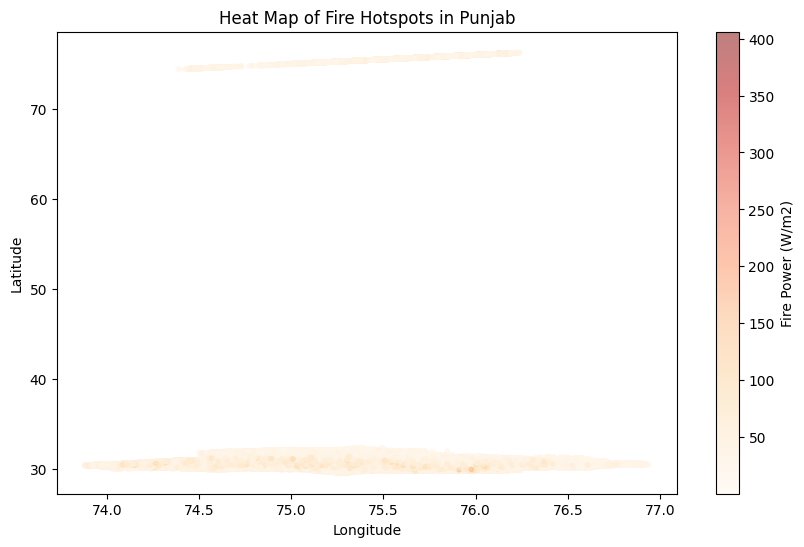

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 

plt.scatter(x=df['Longitude'],y=df['Latitude'],c=df['Fire Power(W/m2)'],cmap='OrRd',alpha=0.5,s=10)        

plt.title('Heat Map of Fire Hotspots in Punjab')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='Fire Power (W/m2)') 
plt.show()